In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import data in df 

df = pd.read_csv('./../../data/raw/synop/synop_2026.csv' , sep=';')
df.describe()

df['rr1']

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
132630    0.0
132631    0.0
132632    0.0
132633    NaN
132634    NaN
Name: rr1, Length: 132635, dtype: float64

Remove 

In [4]:
# Phénomène spécial inutile
df = df.drop(columns=['phenspe1','phenspe2','phenspe3','phenspe4'], errors='ignore')

# On garde que la hauteur de neige tt
df = df.drop(columns=['perssfrai','ssfrai'], errors='ignore')

# On garde que les raffale sur les 10 dernier minute 
df = df.drop(columns=['per','rafper'], errors='ignore')

# On garde que les données des dernier 24h pour la pluie
df = df.drop(columns=['rr1','rr3','rr6','rr12'], errors='ignore')

# que des nan
df = df.drop(columns=['sw'], errors='ignore')

# on garde les temperature sur des periode de 24h 
df = df.drop(columns=['tx12','tn12'], errors='ignore')


df = df.drop(columns=['geop','niv_bar'], errors='ignore')

df = df.drop(columns=['ww','w1','w2'], errors='ignore')

df.describe()

,lat,lon,geo_id_wmo,pmer,tend,cod_tend,dd,ff,t,td,...,hnuage1,nnuage2,ctype2,hnuage2,nnuage3,ctype3,hnuage3,nnuage4,ctype4,hnuage4
count,132635.000000,132635.000000,132635.000000,126045.000000,131527.000000,131527.000000,131198.000000,131198.000000,131990.000000,131000.000000,...,69651.000000,38533.000000,5562.00000,38533.000000,19298.000000,3161.000000,19298.000000,78.000000,5901.000000,78.000000
mean,34.367797,1.248262,21590.859811,101142.553770,13.969755,4.255864,178.710956,4.250355,284.044022,280.332361,...,1520.783190,5.951652,5.28425,2083.633509,6.808218,6.895919,2314.276609,3.192308,8.317404,4470.512821
std,26.390150,50.294291,29441.072367,1085.862503,144.936116,2.725033,97.106817,3.139356,8.464388,7.953043,...,1686.838566,1.826601,2.94460,1798.452958,1.240296,2.849426,1736.303121,2.476160,0.874934,3074.839621
min,-66.663167,-178.121000,7002.000000,95510.000000,-1480.000000,0.000000,0.000000,0.000000,255.250000,221.150000,...,0.000000,1.000000,0.00000,50.000000,1.000000,0.000000,150.000000,1.000000,0.000000,200.000000
25%,43.003833,-0.500167,7190.000000,100520.000000,-70.000000,2.000000,100.000000,2.000000,278.950000,275.850000,...,500.000000,5.000000,3.00000,900.000000,6.000000,8.000000,1170.000000,1.000000,8.000000,1225.000000
50%,45.364000,2.419167,7490.000000,101350.000000,20.000000,3.000000,180.000000,3.500000,282.550000,279.150000,...,900.000000,6.000000,6.00000,1380.000000,7.000000,8.000000,1620.000000,2.000000,8.000000,5350.000000
75%,48.030667,5.427333,7747.000000,101940.000000,100.000000,7.000000,260.000000,5.700000,286.550000,282.350000,...,1740.000000,8.000000,8.00000,2500.000000,8.000000,9.000000,2700.000000,5.000000,9.000000,7500.000000
max,51.055833,167.241167,91958.000000,103890.000000,1760.000000,8.000000,360.000000,32.700000,310.250000,301.750000,...,9000.000000,8.000000,9.00000,9000.000000,8.000000,9.000000,9000.000000,8.000000,9.000000,8000.000000


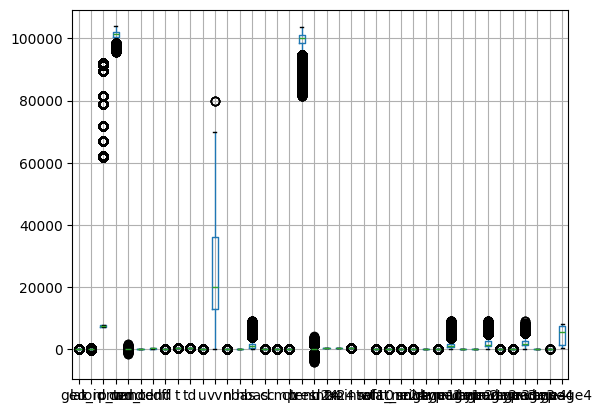

In [ ]:
# df.boxplot()
# plt.show()

In [ ]:
# save in new csv

# df.to_csv('./../../data/pro')

In [5]:
df2 = pd.read_csv('./../../data/raw/FR_E2_2026-01-01.csv' , sep=';')
df2.describe()

df2['couverture de données'].isna().sum()

np.int64(48240)

In [6]:
# que des nan
df2 = df2.drop(columns=['taux de saisie','couverture temporelle','couverture de données'], errors='ignore')

In [7]:
import pandas as pd

# enlever les préfixes ZAG / ZR
df2['city'] = (
    df2['Zas']
    .astype(str)
    .str.replace(r'^(ZAG|ZR)\s*', '', regex=True)
    .str.strip()
)

In [15]:
def _norm_txt(x: str) -> str:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    s = str(x).strip().upper()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    s = s.replace("_", " ").replace("-", " ").replace("'", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

# --- GEO JOIN: relier df2['Zas'] -> (lat, lon) depuis synop ---
# Option A: on vise la position de la station (antenne), pas le centre-ville.
# On fait donc le match en priorité via `df2['nom site']` (nom de station), puis fallback via `Zas`.

df2 = df2.copy()
df2["site_norm"] = df2["nom site"].map(_norm_txt)
df2["zas_norm"] = df2["Zas"].map(_norm_txt)
df2["ville_norm"] = (
    df2["zas_norm"]
    .str.replace(r"^(ZA[GTR]?|ZAS)\s+", "", regex=True)  # retire préfixes fréquents
    .str.replace(r"^ZONE\s+", "", regex=True)
    .str.strip()
)

syn = df[["name", "lat", "lon"]].copy()
syn["name_norm"] = syn["name"].map(_norm_txt)

# Réduction du volume (une ligne par station name_norm)
syn_station = (
    syn.dropna(subset=["name_norm", "lat", "lon"])
    .groupby("name_norm")[["lat", "lon"]]
    .median()
)

# 1) Mapping rapide par station exact (site_norm -> lat/lon)
df2["lat"] = df2["site_norm"].map(syn_station["lat"])
df2["lon"] = df2["site_norm"].map(syn_station["lon"])

# 2) Fallback rapide par ville (token-based, évite les regex par ligne)
def _tokens(norm_txt: str):
    if not norm_txt:
        return []
    return [t for t in re.split(r"[^A-Z0-9]+", norm_txt) if t]

# Table token -> lat/lon (médiane)
syn_station_reset = syn_station.reset_index().rename(columns={"name_norm": "station_norm"})
syn_token_df = syn_station_reset.copy()
syn_token_df["token"] = syn_token_df["station_norm"].map(_tokens)
syn_token_df = syn_token_df.explode("token").dropna(subset=["token"])
token_to_latlon = (
    syn_token_df.groupby("token")[["lat", "lon"]]
    .median()
    .to_dict(orient="index")
)

missing_mask = df2["lat"].isna() | df2["lon"].isna()
ville_missing = df2.loc[missing_mask, "ville_norm"].dropna().unique()
ville_to_lat = {}
ville_to_lon = {}

for ville in ville_missing:
    tokens = _tokens(ville)
    if not tokens:
        continue
    # Choisir le token le plus "spécifique" qui existe dans la table
    best_tok = None
    for tok in sorted(tokens, key=len, reverse=True):
        if tok in token_to_latlon:
            best_tok = tok
            break
    if best_tok is not None:
        ville_to_lat[ville] = float(token_to_latlon[best_tok]["lat"])
        ville_to_lon[ville] = float(token_to_latlon[best_tok]["lon"])

df2["lat"] = df2["lat"].fillna(df2["ville_norm"].map(ville_to_lat))
df2["lon"] = df2["lon"].fillna(df2["ville_norm"].map(ville_to_lon))

# qualité du join (coordonnées non manquantes)

print("Geo join ok:", int(df2["lat"].notna().sum()), "/", len(df2))

# --- TIME JOIN: relier df (synop) <-> df2 (pollution) ---
# Règle: même `lat/lon` (arrondis) et même heure (floor à l'heure).

LAT_DECIMALS = 4

def _floor_hour_utc(dt_series: pd.Series) -> pd.Series:
    """Parse + floor à l'heure. Sortie: datetime naive UTC (sans tz)."""
    dt = pd.to_datetime(dt_series, errors="coerce")
    if hasattr(dt.dt, "tz_localize"):
        # si c'est déjà tz-aware, convertit en UTC, sinon localise en Europe/Paris puis convertit.
        if getattr(dt.dt, "tz", None) is not None:
            return dt.dt.tz_convert("UTC").dt.floor("h").dt.tz_localize(None)
    # case naive: on suppose Europe/Paris (heure locale de FR_E2)
    dt_utc = dt.dt.tz_localize("Europe/Paris", ambiguous="infer", nonexistent="shift_forward").dt.tz_convert("UTC")
    return dt_utc.dt.floor("h").dt.tz_localize(None)

# clés spatiales arrondies (stabilité du merge)
df2["lat_r"] = df2["lat"].round(LAT_DECIMALS)
df2["lon_r"] = df2["lon"].round(LAT_DECIMALS)

# heure df2 (colonne: "Date de début")
df2["hour_utc"] = _floor_hour_utc(df2["Date de début"])

# heure synop df (colonne: reference_time, typée avec un suffixe Z => UTC)
df["lat_r"] = df["lat"].round(LAT_DECIMALS)
df["lon_r"] = df["lon"].round(LAT_DECIMALS)
df["hour_utc"] = pd.to_datetime(df["reference_time"], errors="coerce", utc=True).dt.floor("h").dt.tz_localize(None)

# Filtrer synop sur la fenêtre temporelle de df2 (accélère énormément)
min_hour = df2["hour_utc"].min()
max_hour = df2["hour_utc"].max()
if pd.notna(min_hour) and pd.notna(max_hour):
    pad = pd.Timedelta(days=2)
    df_syn_sub = df[df["hour_utc"].between(min_hour - pad, max_hour + pad)].copy()
else:
    df_syn_sub = df

# Agréger synop au niveau (station lat/lon + heure)
keys = ["lat_r", "lon_r", "hour_utc"]
df_syn_hourly = (
    df_syn_sub.groupby(keys)
    .mean(numeric_only=True)
    .reset_index()
)

# Merge (ajoute les variables synop à chaque mesure df2)
meteo_cols = [c for c in df_syn_hourly.columns if c not in keys]
df_out = df2.merge(
    df_syn_hourly[keys + meteo_cols],
    on=keys,
    how="left",
    suffixes=("", "_synop"),
)

matched_mask = df_out[meteo_cols].notna().any(axis=1)

# 1) Données jointes (df2 enrichi météo) : on supprime les non-match
df_joined = df_out.loc[matched_mask].copy()

# 2) Données df2 non match (pollution sans météo)
df2_not_matched = df_out.loc[~matched_mask].copy()

# df_out ne garde que les lignes matchées
df_out = df_joined

# 3) Données météo non match (météo sans pollution)
df2_keys_unique = df2[keys].dropna().drop_duplicates()
df_syn_not_matched = (
    df_syn_hourly.merge(df2_keys_unique, on=keys, how="left", indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns=["_merge"])
)

print("Time join ok:", int(matched_mask.sum()), "/", len(df_out))
print("df2_not_matched:", len(df2_not_matched))
print("df_syn_not_matched:", len(df_syn_not_matched))

# df_joined = dataset final (df2 + météo) ; les 2 autres servent à analyser les non-matchs

df_out.columns

Geo join ok: 36696 / 48240
Time join ok: 36696 / 36696
df2_not_matched: 11544
df_syn_not_matched: 4181


Index(['Date de début', 'Date de fin', 'Organisme', 'code zas', 'Zas',
       'code site', 'nom site', 'type d'implantation', 'Polluant',
       'type d'influence', 'discriminant', 'Réglementaire',
       'type d'évaluation', 'procédure de mesure', 'type de valeur', 'valeur',
       'valeur brute', 'unité de mesure', 'code qualité', 'validité', 'city',
       'site_norm', 'zas_norm', 'ville_norm', 'lat', 'lon', 'lat_r', 'lon_r',
       'hour_utc', 'lat_synop', 'lon_synop', 'geo_id_wmo', 'pmer', 'tend',
       'cod_tend', 'dd', 'ff', 't', 'td', 'u', 'vv', 'n', 'nbas', 'hbas', 'cl',
       'cm', 'ch', 'pres', 'tend24', 'tn24', 'tx24', 'tminsol', 'tw', 'raf10',
       'etat_sol', 'ht_neige', 'rr24', 'nnuage1', 'ctype1', 'hnuage1',
       'nnuage2', 'ctype2', 'hnuage2', 'nnuage3', 'ctype3', 'hnuage3',
       'nnuage4', 'ctype4', 'hnuage4'],
      dtype='str')

In [20]:
import json
import pandas as pd
import numpy as np

def export_features(
    df: pd.DataFrame,
    path_out: str = "C:/Users/benja/Documents/Ynov202526/Challenge 48h/data/src/processing/features.json",
    id_col: str = "geo_id_wmo",     # ou "code site" etc.
    name_col: str = "name",         # ou "Nom"
    lon_col: str = "lon",
    lat_col: str = "lat",
    extra_props: dict | None = None # ex: {"Altitude": "alt", "Date_ouverture": "date_ouverture"}
):
    extra_props = extra_props or {}

    d = df_out.copy()

    # on ne garde qu'1 ligne par (nom, lat, lon) pour éviter les doublons
    cols_needed = [c for c in [id_col, name_col, lon_col, lat_col] if c in d.columns]
    d = d[cols_needed + [c for c in extra_props.values() if c in d.columns]].drop_duplicates()

    features = []
    for _, r in d.iterrows():
        lon = r.get(lon_col, np.nan)
        lat = r.get(lat_col, np.nan)

        # si pas de coords, on skip (tu peux enlever ce if si tu veux garder quand même)
        if pd.isna(lon) or pd.isna(lat):
            continue

        props = {
            "Id": None if id_col not in d.columns else (None if pd.isna(r.get(id_col)) else str(r.get(id_col))),
            "Nom": None if name_col not in d.columns else (None if pd.isna(r.get(name_col)) else str(r.get(name_col))),
        }

        # propriétés optionnelles
        for out_key, src_col in extra_props.items():
            val = r.get(src_col, None)
            if pd.isna(val):
                val = None
            elif isinstance(val, (np.integer, np.floating)):
                val = float(val)
            props[out_key] = val

        features.append({
            "type": "Feature",
            "properties": props,
            "geometry": {
                "type": "Point",
                "coordinates": [float(lon), float(lat)],
            },
        })

    with open(path_out, "w", encoding="utf-8") as f:
        json.dump(features, f, ensure_ascii=False, indent=2)

    return features

# Exemple d’usage (synop)
# features = export_features(df, "stations_features.json", id_col="geo_id_wmo", name_col="name")

# Exemple d’usage (pollution+meteo joint, si tu as lat/lon déjà)
# features = export_features(df_out, "zas_features.json", id_col="code zas", name_col="Zas")

In [22]:
df.to_csv("./../../data/processed/df.csv", index=False, encoding="utf-8")